# Workshop 1 - Bugs: Transfer Learning + Confusion Matrix

จำแนกภาพแมลงศัตรูพืช 20 ชนิด ด้วย transfer learning แล้วดูผลด้วย confusion matrix

ลำดับการทำ: โหลดข้อมูล → เตรียม pipeline → ฝึก CNN เองไว้เป็นตัวเทียบ → transfer learning (feature extraction แล้วต่อด้วย fine-tuning) → เทียบ base model สองตัว → confusion matrix

ชุดข้อมูลคือ IP102 ซึ่งเป็นชุดมาตรฐานสำหรับงานจำแนกแมลงศัตรูพืช งานนี้คัดมา 20 คลาสที่มีภาพมากที่สุด รวมราว 10,000 ภาพ

โจทย์นี้ยากกว่าชุดดอกไม้ที่ใช้กันทั่วไปมาก เพราะหลายคลาสเป็นแมลงในวงศ์เดียวกัน เช่น *blister beetle* กับ *legume blister beetle* กับ *lytta polita* ล้วนเป็นด้วงน้ำมัน และภาพจำนวนมากถ่ายในไร่จริง มีใบไม้บังหรือแมลงตัวเล็กมากในเฟรม

**คำเตือนเรื่องเวลา:** ข้อมูลหมื่นภาพกับ ResNet50V2 (25M พารามิเตอร์) ควรรันบน GPU ถ้ารันบน CPU จะใช้เวลาหลายชั่วโมง บน Colab เปิด GPU ที่ `Runtime > Change runtime type > GPU`

## 0. เตรียมสภาพแวดล้อม

In [1]:
import pathlib
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow import keras
from tensorflow.keras import layers

keras.utils.set_random_seed(42)

print("TensorFlow :", tf.__version__)
print("GPU        :", tf.config.list_physical_devices('GPU'))

TensorFlow : 2.21.0
GPU        : []


matplotlib ใช้ฟอนต์ที่ไม่มีตัวอักษรไทย ข้อความไทยบนกราฟจะกลายเป็นสี่เหลี่ยม เซลล์นี้หาฟอนต์ไทยในเครื่องมาตั้งเป็นค่าเริ่มต้น

In [2]:
import matplotlib
from matplotlib import font_manager

THAI_FONTS = ['Sarabun', 'Noto Sans Thai', 'Thonburi', 'Leelawadee UI', 'Tahoma', 'Ayuthaya']

available = {f.name for f in font_manager.fontManager.ttflist}
thai_font = next((f for f in THAI_FONTS if f in available), None)

if thai_font:
    matplotlib.rcParams['font.family'] = thai_font
    matplotlib.rcParams['axes.unicode_minus'] = False
    print("ใช้ฟอนต์:", thai_font)
else:
    print("ไม่พบฟอนต์ไทย - ถ้ารันบน Colab: !apt-get install -y fonts-thai-tlwg แล้ว restart runtime")

ใช้ฟอนต์: Sarabun


## 1. โหลดชุดข้อมูล

IP102 เวอร์ชันนี้โหลดตรงจาก Hugging Face ได้ ไม่ต้องใช้ token ไฟล์ zip ขนาด 641MB มี 15,178 ภาพ 97 คลาส

แต่ภาพทั้งหมดกองรวมอยู่ในโฟลเดอร์เดียว ส่วนคลาสอยู่ในไฟล์ `IP102_data.csv` เราจึงต้องจัดภาพเข้าโฟลเดอร์ตามคลาสเอง เพราะ `image_dataset_from_directory` อ่านชื่อคลาสจากชื่อโฟลเดอร์

In [3]:
import zipfile, csv, collections, shutil

URL = "https://huggingface.co/datasets/P147852369/Insects/resolve/main/MD-IP102.zip"

zip_path = keras.utils.get_file("MD-IP102.zip", origin=URL)
extract_dir = pathlib.Path(zip_path).parent / "MD-IP102-extracted"

if not extract_dir.exists():
    print("กำลังแตกไฟล์...")
    with zipfile.ZipFile(zip_path) as z:
        z.extractall(extract_dir)

src_dir = extract_dir / "MD-IP102"
print("โฟลเดอร์ที่แตกแล้ว:", src_dir)
print("จำนวนภาพทั้งหมด   :", len(list((src_dir / "images").glob("*.jpg"))))

โฟลเดอร์ที่แตกแล้ว: /Users/pasunimsuwan/.keras/datasets/MD-IP102-extracted/MD-IP102
จำนวนภาพทั้งหมด   : 15178


คัด 20 คลาสที่มีภาพมากที่สุด แล้วคัดลอกภาพเข้าโฟลเดอร์ตามชื่อคลาส

ชื่อคลาสบางตัวมีช่องว่าง เปลี่ยนเป็น `_` เพื่อให้อ่านง่ายบนกราฟ

In [4]:
N_CLASSES = 20

with open(src_dir / "IP102_data.csv", encoding="utf-8-sig") as f:
    rows = list(csv.DictReader(f))

counts = collections.Counter(r['category_name'] for r in rows)
top_classes = [name for name, _ in counts.most_common(N_CLASSES)]

data_dir = extract_dir / "by_class"

if not data_dir.exists():
    wanted = set(top_classes)
    for r in rows:
        label = r['category_name']
        if label not in wanted:
            continue
        src = src_dir / "images" / f"{r['image_id']}.jpg"
        if not src.exists():
            continue
        dst_dir = data_dir / label.replace(' ', '_')
        dst_dir.mkdir(parents=True, exist_ok=True)
        shutil.copy(src, dst_dir / src.name)

total = 0
for folder in sorted(data_dir.iterdir()):
    n = len(list(folder.glob('*.jpg')))
    total += n
    print(f"  {folder.name:<30} {n:>5} ภาพ")
print(f"\n  รวม {N_CLASSES} คลาส {total:,} ภาพ")

  Ampelophaga                      223 ภาพ
  Cicadellidae                    2345 ภาพ
  Locustoidea                      426 ภาพ
  Lycorma_delicatula               270 ภาพ
  Miridae                         1012 ภาพ
  Prodenia_litura                  331 ภาพ
  aphids                           701 ภาพ
  beet_army_worm                   330 ภาพ
  black_cutworm                    240 ภาพ
  blister_beetle                   748 ภาพ
  cabbage_army_worm                197 ภาพ
  corn_borer                       339 ภาพ
  flax_budworm                     328 ภาพ
  flea_beetle                      276 ภาพ
  grub                             349 ภาพ
  legume_blister_beetle            348 ภาพ
  lytta_polita                     195 ภาพ
  mole_cricket                     695 ภาพ
  tarnished_plant_bug              278 ภาพ
  wireworm                         339 ภาพ

  รวม 20 คลาส 9,970 ภาพ


สังเกตว่าจำนวนภาพต่อคลาสต่างกันมาก คลาสใหญ่สุด (Cicadellidae เพลี้ยจักจั่น) มีราว 2,300 ภาพ ส่วนคลาสเล็กสุดมีไม่ถึง 200 ภาพ ต่างกันเกิน 10 เท่า

ความไม่สมดุลระดับนี้มีผลจริงต่อการอ่านผล โมเดลจะเอนไปทางคลาสใหญ่ และ accuracy รวมจะดูดีเกินจริง ตอนดู confusion matrix จึงต้องดูเป็นเปอร์เซ็นต์ต่อแถว ไม่ใช่จำนวนดิบ และต้องดู recall รายคลาสประกอบเสมอ

## 2. เตรียม data pipeline

`image_dataset_from_directory` อ่านไฟล์ ย่อขนาด และติด label จากชื่อโฟลเดอร์ให้ในคำสั่งเดียว

- `image_size=(224, 224)` ตรงกับขนาดที่โมเดลสำเร็จรูปถูกฝึกมา
- `validation_split=0.2` กันไว้ 20% สำหรับวัดผล
- `seed=42` ต้องเป็นเลขเดียวกันทั้งสองชุด ไม่งั้นภาพจะปนกันระหว่าง train กับ validation

In [5]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

train_ds = keras.utils.image_dataset_from_directory(
    data_dir, validation_split=0.2, subset='training', seed=42,
    image_size=IMG_SIZE, batch_size=BATCH_SIZE, label_mode='int',
)

val_ds = keras.utils.image_dataset_from_directory(
    data_dir, validation_split=0.2, subset='validation', seed=42,
    image_size=IMG_SIZE, batch_size=BATCH_SIZE, label_mode='int',
)

class_names = train_ds.class_names
print("\nคลาส:", class_names)

Found 9970 files belonging to 20 classes.
Using 7976 files for training.
Found 9970 files belonging to 20 classes.
Using 1994 files for validation.

คลาส: ['Ampelophaga', 'Cicadellidae', 'Locustoidea', 'Lycorma_delicatula', 'Miridae', 'Prodenia_litura', 'aphids', 'beet_army_worm', 'black_cutworm', 'blister_beetle', 'cabbage_army_worm', 'corn_borer', 'flax_budworm', 'flea_beetle', 'grub', 'legume_blister_beetle', 'lytta_polita', 'mole_cricket', 'tarnished_plant_bug', 'wireworm']


ดูภาพกับ label สักชุดก่อน เพื่อยืนยันว่าข้อมูลถูกต้อง

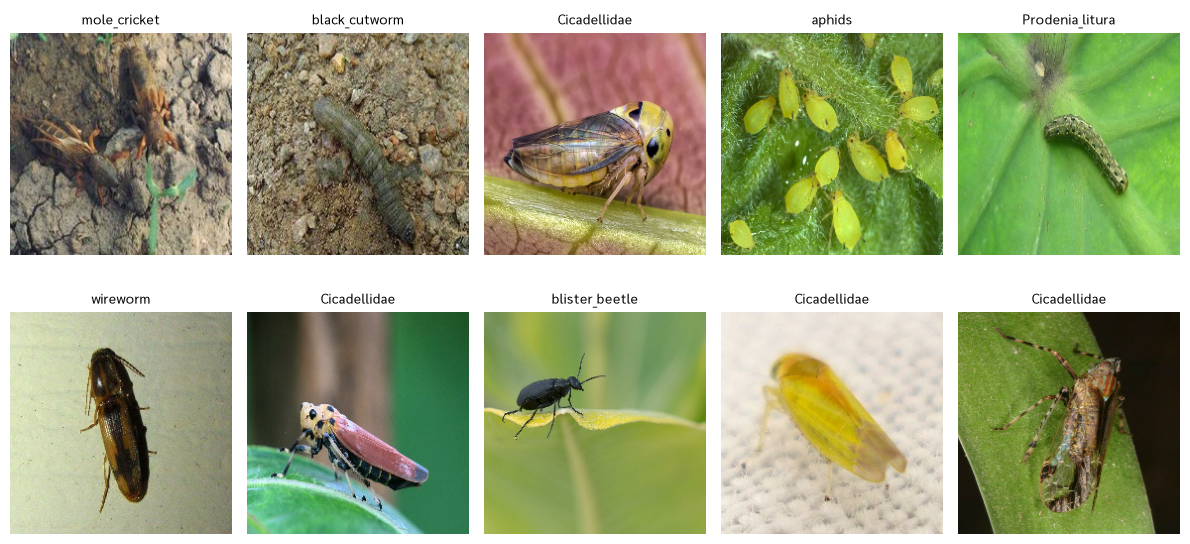

รูปทรง batch : (32, 224, 224, 3)
ช่วงพิกเซล   : 0.0 ถึง 255.0


In [6]:
images, labels = next(iter(train_ds))

plt.figure(figsize=(12, 6))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(images[i].numpy().astype('uint8'))
    plt.title(class_names[labels[i]], fontsize=10)
    plt.axis('off')
plt.tight_layout()
plt.show()

print("รูปทรง batch :", images.shape)
print("ช่วงพิกเซล   :", float(images.numpy().min()), "ถึง", float(images.numpy().max()))

พิกเซลยังเป็น 0-255 อยู่ ตรงนี้ยังไม่ normalize เพราะแต่ละ base model ต้องการช่วงค่าไม่เหมือนกัน จึงปล่อยให้เป็นหน้าที่ของโมเดลแต่ละตัวในส่วนที่ 4

ต่อไปใส่ `cache()` (อ่านดิสก์รอบเดียว) และ `prefetch()` (เตรียม batch ถัดไปขณะคำนวณ batch ปัจจุบัน) เพื่อให้ฝึกเร็วขึ้น

ข้อมูลหมื่นภาพที่ 224×224 กิน RAM ราว 6GB ถ้า `cache()` ไว้ในหน่วยความจำ ถ้าเครื่องไม่พอให้เปลี่ยนเป็น `cache("cache.tf")` เพื่อ cache ลงดิสก์แทน

In [7]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.cache().shuffle(2000).prefetch(AUTOTUNE)
val_ds = val_ds.cache().prefetch(AUTOTUNE)

ใส่ augmentation สุ่มพลิก/หมุน/ซูมทุกครั้งที่โมเดลเห็นภาพ ช่วยลด overfitting ชั้นพวกนี้ทำงานเฉพาะตอนฝึก ตอน evaluate กับ predict Keras ปิดให้เอง

ภาพแมลงถ่ายจากมุมไหนก็ได้ จึงเปิด `RandomFlip` ทั้งแนวนอนและแนวตั้งได้ ต่างจากภาพวัตถุที่มีบนล่างชัดเจน

In [8]:
data_augmentation = keras.Sequential([
    layers.RandomFlip('horizontal_and_vertical'),
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.2),
    layers.RandomContrast(0.2),
], name='data_augmentation')

## 3. Baseline: CNN ที่ฝึกเองจากศูนย์

ต้องมีตัวเทียบก่อน ไม่งั้นจะไม่รู้ว่า transfer learning ดีขึ้นจริงแค่ไหน โมเดลนี้เริ่มจากน้ำหนักสุ่มทั้งหมด

In [9]:
baseline = keras.Sequential([
    layers.Input((224, 224, 3)),
    data_augmentation,
    layers.Rescaling(1./255),

    layers.Conv2D(32, 3, activation='relu'),
    layers.MaxPooling2D(),
    layers.Conv2D(64, 3, activation='relu'),
    layers.MaxPooling2D(),
    layers.Conv2D(128, 3, activation='relu'),
    layers.MaxPooling2D(),
    layers.Conv2D(256, 3, activation='relu'),
    layers.MaxPooling2D(),

    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.3),
    layers.Dense(len(class_names), activation='softmax'),
], name='baseline_cnn')

baseline.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
baseline.summary()

Model: "baseline_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 24, 24, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 12, 12, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 20)             │         5,140 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 393,556 (1.50 MB)

 Trainable params: 393,556 (1.50 MB)

 Non-trainable params: 0 (0.00 B)

In [10]:
history_baseline = baseline.fit(train_ds, validation_data=val_ds, epochs=10)

Epoch 1/10


/Users/pasunimsuwan/Desktop/DPU/DT-509/W1/Workshop/.venv/lib/python3.12/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


250/250 ━━━━━━━━━━━━━━━━━━━━ 115s 443ms/step - accuracy: 0.2408 - loss: 2.6576 - val_accuracy: 0.2578 - val_loss: 2.5124
Epoch 2/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 108s 433ms/step - accuracy: 0.2741 - loss: 2.4502 - val_accuracy: 0.2854 - val_loss: 2.4363
Epoch 3/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 111s 444ms/step - accuracy: 0.2891 - loss: 2.3889 - val_accuracy: 0.2773 - val_loss: 2.5000
Epoch 4/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 110s 441ms/step - accuracy: 0.2998 - loss: 2.3271 - val_accuracy: 0.3019 - val_loss: 2.3133
Epoch 5/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 104s 415ms/step - accuracy: 0.3117 - loss: 2.2731 - val_accuracy: 0.3159 - val_loss: 2.3412
Epoch 6/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 111s 445ms/step - accuracy: 0.3202 - loss: 2.2508 - val_accuracy: 0.3285 - val_loss: 2.1979
Epoch 7/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 107s 426ms/step - accuracy: 0.3301 - loss: 2.2103 - val_accuracy: 0.3330 - val_loss: 2.1392
Epoch 8/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 111s 446ms/step - accuracy: 0.3374 - loss: 2.17

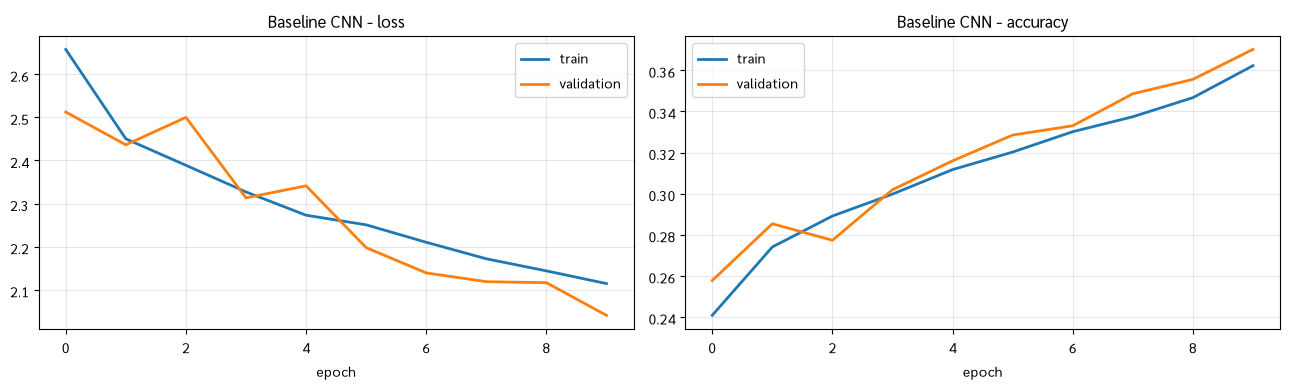

Baseline CNN - val accuracy สูงสุด: 0.3701


In [11]:
def plot_history(history, title=""):
    h = history.history
    fig, ax = plt.subplots(1, 2, figsize=(13, 4))

    for i, metric in enumerate(['loss', 'accuracy']):
        ax[i].plot(h[metric], label='train', linewidth=2)
        ax[i].plot(h['val_' + metric], label='validation', linewidth=2)
        ax[i].set_title(f'{title} - {metric}')
        ax[i].set_xlabel('epoch')
        ax[i].legend()
        ax[i].grid(alpha=0.3)

    plt.tight_layout()
    plt.show()


plot_history(history_baseline, "Baseline CNN")

baseline_acc = max(history_baseline.history['val_accuracy'])
print(f"Baseline CNN - val accuracy สูงสุด: {baseline_acc:.4f}")

Baseline จะได้ราว 20-30% ซึ่งดีกว่าเดาสุ่ม (5%) อยู่มาก แต่ยังต่ำ เพราะ 20 คลาสที่หน้าตาใกล้กันเป็นโจทย์ที่ยากเกินกว่า CNN เล็ก ๆ ที่ฝึกจากศูนย์ด้วยข้อมูลเท่านี้

## 4. Transfer learning ขั้นที่ 1: feature extraction

โมเดลที่ฝึกมาบน ImageNet เรียนรู้การมองภาพไว้แล้ว ชั้นต้นจับเส้นขอบและสี ชั้นลึกจับรูปทรง ความรู้พวกนี้ใช้กับภาพแมลงได้เลย เราจึงตัดหัวเดิมที่ทำนาย 1,000 คลาสทิ้ง เก็บส่วนที่เหลือไว้เป็น feature extractor แล้วต่อหัวใหม่ที่ทำนาย 20 คลาส

`base.trainable = False` คือหัวใจของขั้นนี้ - ฝึกเฉพาะชั้น Dense ท้ายสุด น้ำหนักเดิมไม่ถูกแตะ

งานนี้เทียบ base model สองตัว

| | EfficientNetV2B0 | ResNet50V2 |
|---|---|---|
| พารามิเตอร์ | ~5.9M | ~23.6M |
| preprocessing | มี normalization ในตัว ป้อน 0-255 ได้เลย | ต้องเรียก `preprocess_input` เอง |
| จุดเด่น | เล็กกว่า 4 เท่า ออกแบบมาให้คุ้มค่าคำนวณ | สถาปัตยกรรมคลาสสิก ชั้นลึกกว่า |

`preprocess_input` ต้องตรงกับ base model เสมอ ใส่ผิดตัวจะไม่มี error แต่ accuracy ตกโดยไม่รู้สาเหตุ ตรงนี้จึงผูกไว้ในตารางเดียวกับ base model

In [12]:
CONFIGS = {
    'EfficientNetV2B0': dict(
        builder=keras.applications.EfficientNetV2B0,
        preprocess=None,          # มี normalization ในตัวแล้ว
        fine_tune_layers=30,
    ),
    'ResNet50V2': dict(
        builder=keras.applications.ResNet50V2,
        preprocess=keras.applications.resnet_v2.preprocess_input,
        fine_tune_layers=30,
    ),
}

ฟังก์ชันสามตัวนี้ใช้ซ้ำกับทุก base model - สร้างโมเดล, ฝึก feature extraction, แล้ว fine-tune ต่อ

จุดที่ต้องระวังตอน fine-tune มีสองข้อ

1. ปลดล็อกเฉพาะชั้นท้าย ชั้นต้นจับเส้นขอบกับสีซึ่งใช้กับภาพทุกชนิดได้อยู่แล้ว ไม่ควรแตะ
2. ลด learning rate จาก `1e-3` เหลือ `1e-5` ถ้าใช้ค่าเดิม gradient ก้อนใหญ่จะทำลายน้ำหนักที่ ImageNet ฝึกมา (catastrophic forgetting)

และต้อง `compile()` ใหม่หลังเปลี่ยน `trainable` ไม่งั้น Keras ยังใช้ค่าที่ compile ไว้เดิม

In [13]:
EPOCHS_FE = 10
EPOCHS_FT = 10


def build_model(cfg, name):
    base = cfg['builder'](include_top=False, weights='imagenet', input_shape=(224, 224, 3))
    base.trainable = False

    inputs = keras.Input(shape=(224, 224, 3))
    x = data_augmentation(inputs)
    if cfg['preprocess'] is not None:
        x = cfg['preprocess'](x)
    x = base(x, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.2)(x)
    outputs = layers.Dense(len(class_names), activation='softmax')(x)

    model = keras.Model(inputs, outputs, name=name)
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy'],
    )
    return model, base


def fine_tune(model, base, n_layers):
    base.trainable = True

    fine_tune_from = len(base.layers) - n_layers
    for layer in base.layers[:fine_tune_from]:
        layer.trainable = False

    # BatchNorm ต้องตรึงไว้ ไม่งั้นสถิติ mean/variance จะเพี้ยน
    for layer in base.layers[fine_tune_from:]:
        if isinstance(layer, layers.BatchNormalization):
            layer.trainable = False

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-5),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy'],
    )
    return sum(int(tf.size(w)) for w in model.trainable_weights)


def run(name, cfg):
    print(f"\n{'=' * 60}\n{name}\n{'=' * 60}")

    model, base = build_model(cfg, name)
    fe_trainable = sum(int(tf.size(w)) for w in model.trainable_weights)
    print(f"ชั้นใน base model : {len(base.layers)}")
    print(f"ฝึกได้ตอน FE      : {fe_trainable:,} จาก {model.count_params():,}\n")

    history_fe = model.fit(train_ds, validation_data=val_ds, epochs=EPOCHS_FE)

    ft_trainable = fine_tune(model, base, cfg['fine_tune_layers'])
    print(f"\nfine-tune {cfg['fine_tune_layers']} ชั้นท้าย - ฝึกได้ {ft_trainable:,} พารามิเตอร์\n")

    history_ft = model.fit(
        train_ds, validation_data=val_ds,
        epochs=EPOCHS_FE + EPOCHS_FT, initial_epoch=EPOCHS_FE,
    )

    return dict(
        name=name,
        model=model,
        history_fe=history_fe,
        history_ft=history_ft,
        fe_acc=max(history_fe.history['val_accuracy']),
        ft_acc=max(history_ft.history['val_accuracy']),
        fe_trainable=fe_trainable,
        ft_trainable=ft_trainable,
        total_params=model.count_params(),
    )

รันทั้งสองตัว ส่วนนี้กินเวลานานที่สุดของโน้ตบุ๊ก

บน Colab GPU (T4) ประมาณ 25-40 นาที ถ้ารันบน CPU จะหลายชั่วโมง - ตอนลองครั้งแรกแนะนำให้ลด `EPOCHS_FE` กับ `EPOCHS_FT` เหลืออย่างละ 3 ก่อน เพื่อดูว่าทั้ง flow ทำงาน แล้วค่อยเพิ่มเป็น 10

In [14]:
results = {name: run(name, cfg) for name, cfg in CONFIGS.items()}


EfficientNetV2B0
ชั้นใน base model : 270
ฝึกได้ตอน FE      : 25,620 จาก 5,944,932

Epoch 1/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 76s 283ms/step - accuracy: 0.5969 - loss: 1.3896 - val_accuracy: 0.6901 - val_loss: 0.9345
Epoch 2/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 68s 272ms/step - accuracy: 0.7184 - loss: 0.8851 - val_accuracy: 0.7257 - val_loss: 0.8032
Epoch 3/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 64s 257ms/step - accuracy: 0.7480 - loss: 0.7765 - val_accuracy: 0.7392 - val_loss: 0.7457
Epoch 4/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 63s 251ms/step - accuracy: 0.7632 - loss: 0.7244 - val_accuracy: 0.7523 - val_loss: 0.7167
Epoch 5/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 63s 252ms/step - accuracy: 0.7762 - loss: 0.6876 - val_accuracy: 0.7457 - val_loss: 0.7236
Epoch 6/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 72s 289ms/step - accuracy: 0.7790 - loss: 0.6712 - val_accuracy: 0.7553 - val_loss: 0.7045
Epoch 7/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 66s 266ms/step - accuracy: 0.7877 - loss: 0.6409 - val_accuracy: 0.7658 - val_loss: 0.6856

## 5. เทียบผลสองโมเดล

วาดกราฟทั้งสองตัวซ้อนกัน เส้นประแดงคือจุดที่เริ่ม fine-tune

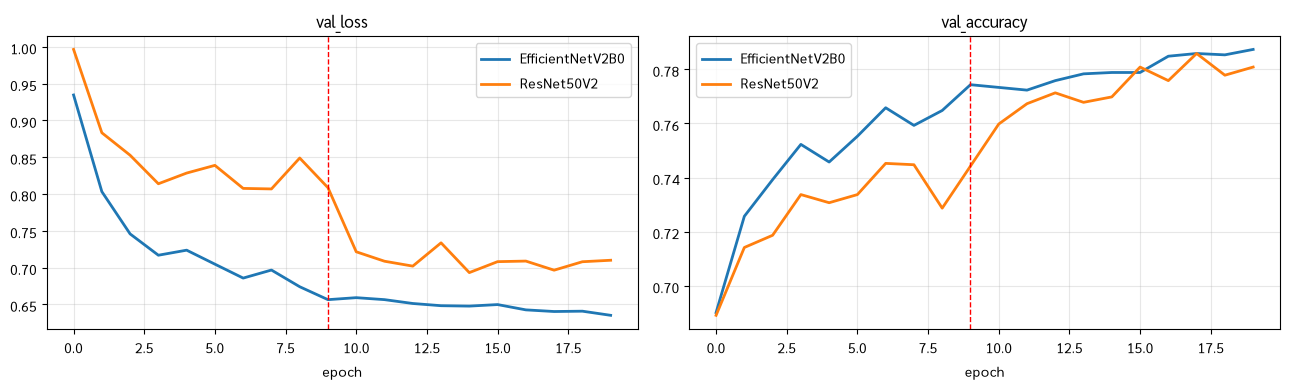

base model          FE        FT        params
EfficientNetV2B0    0.7743    0.7874    5,944,932
ResNet50V2          0.7452    0.7859    23,605,780


In [15]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4))

for r in results.values():
    h = {k: r['history_fe'].history[k] + r['history_ft'].history[k] for k in r['history_fe'].history}
    for i, metric in enumerate(['val_loss', 'val_accuracy']):
        ax[i].plot(h[metric], label=r['name'], linewidth=2)

for i, metric in enumerate(['val_loss', 'val_accuracy']):
    ax[i].axvline(EPOCHS_FE - 1, color='red', linestyle='--', linewidth=1)
    ax[i].set_title(metric)
    ax[i].set_xlabel('epoch')
    ax[i].legend()
    ax[i].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"{'base model':<20}{'FE':<10}{'FT':<10}{'params'}")
for r in results.values():
    print(f"{r['name']:<20}{r['fe_acc']:<10.4f}{r['ft_acc']:<10.4f}{r['total_params']:,}")

เลือกตัวที่ได้ val accuracy สูงสุดหลัง fine-tune ไปทำ confusion matrix ต่อ

In [16]:
best = max(results.values(), key=lambda r: r['ft_acc'])
model = best['model']

print("โมเดลที่เลือก:", best['name'])

โมเดลที่เลือก: EfficientNetV2B0


## 6. Confusion matrix

Accuracy บอกแค่ว่าถูกกี่เปอร์เซ็นต์ แต่ไม่บอกว่าผิดตรงไหน confusion matrix บอกครบ: แถวคือคำตอบจริง คอลัมน์คือสิ่งที่โมเดลทาย ช่องแนวทแยงคือทายถูก

In [17]:
from sklearn.metrics import confusion_matrix, classification_report

y_true, y_pred, y_prob = [], [], []

for batch_images, batch_labels in val_ds:
    probs = model.predict(batch_images, verbose=0)
    y_true.extend(batch_labels.numpy())
    y_pred.extend(probs.argmax(axis=1))
    y_prob.extend(probs.max(axis=1))

y_true = np.array(y_true)
y_pred = np.array(y_pred)
y_prob = np.array(y_prob)

print(f"ทำนาย {len(y_true)} ภาพ  ถูก {int((y_true == y_pred).sum())}  ผิด {int((y_true != y_pred).sum())}")
print(f"accuracy = {(y_true == y_pred).mean():.4f}")

ทำนาย 1994 ภาพ  ถูก 1570  ผิด 424
accuracy = 0.7874


20 คลาสทำให้ตารางมี 400 ช่อง ใส่ตัวเลขทุกช่องจะอ่านไม่ออก จึงวาดด้วยสีอย่างเดียว แล้วเขียนตัวเลขเฉพาะช่องที่มีค่าตั้งแต่ 5% ขึ้นไป

อ่านจากสี: แนวทแยงเข้ม = ทายถูกเยอะ ช่องนอกแนวทแยงที่เข้มผิดปกติ = คู่ที่โมเดลสับสน ส่วนแถวที่จาง ๆ ทั้งแถว = คลาสที่โมเดลแทบจับไม่ได้เลย

ค่าในช่อง (แถว A, คอลัมน์ B) คือ "ภาพที่จริง ๆ เป็น A มีกี่ % ที่โมเดลทายว่าเป็น B" แต่ละแถวรวมกันได้ 100%

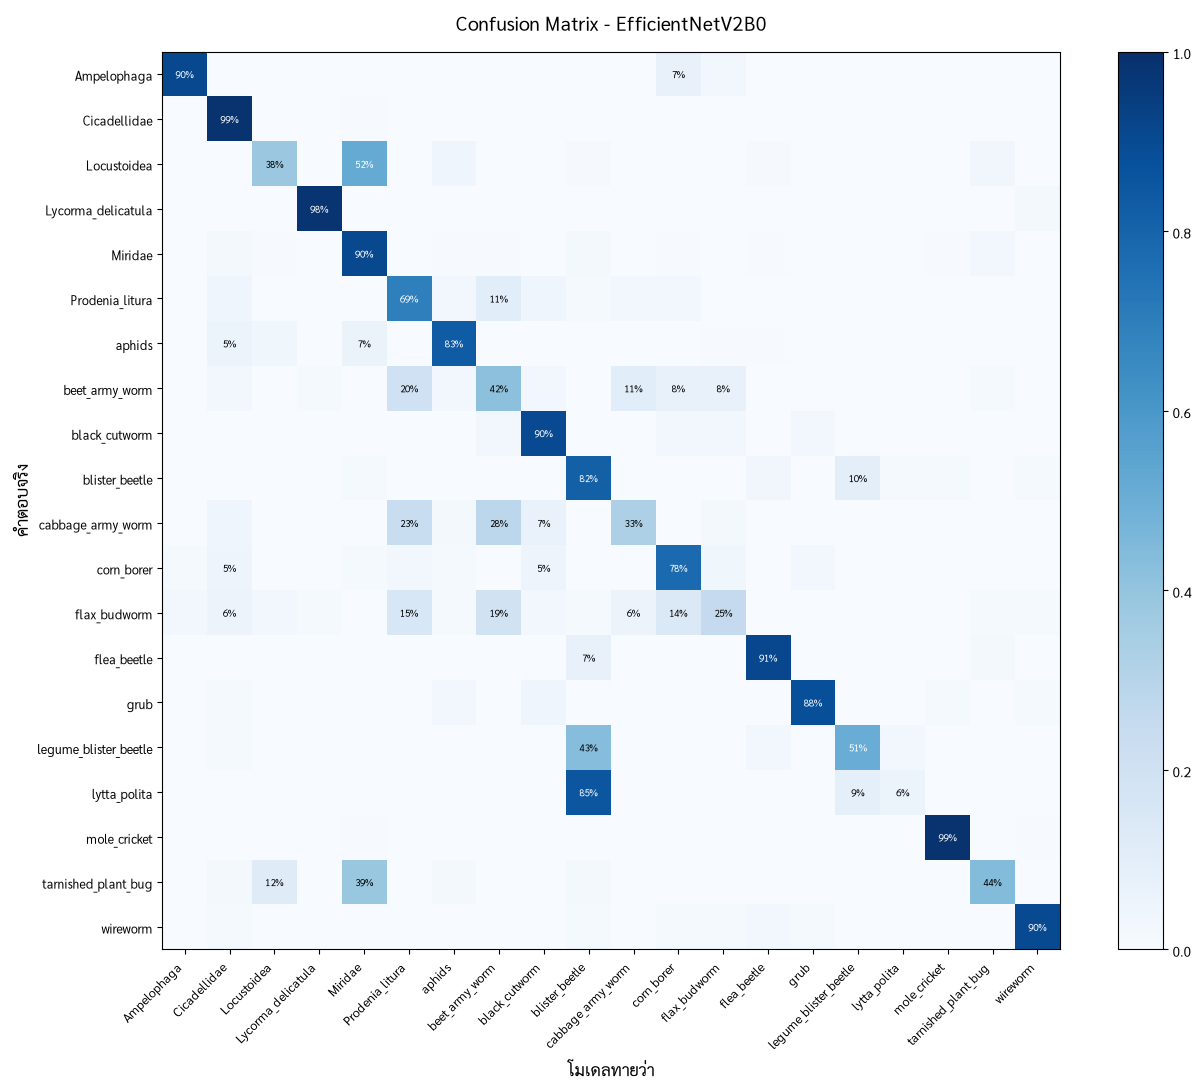

In [18]:
cm = confusion_matrix(y_true, y_pred)
cm_norm = cm.astype('float') / cm.sum(axis=1, keepdims=True)

fig, ax = plt.subplots(figsize=(13, 11))
im = ax.imshow(cm_norm, cmap='Blues', vmin=0, vmax=1)

ax.set_xticks(range(len(class_names)), class_names, rotation=45, ha='right', fontsize=9)
ax.set_yticks(range(len(class_names)), class_names, fontsize=9)
ax.set_xlabel('โมเดลทายว่า', fontsize=12)
ax.set_ylabel('คำตอบจริง', fontsize=12)
ax.set_title(f"Confusion Matrix - {best['name']}", fontsize=14, pad=15)

# เขียนตัวเลขเฉพาะช่องที่มีค่าพอสมควร ไม่งั้น 400 ช่องจะอ่านไม่ออก
for i in range(len(class_names)):
    for j in range(len(class_names)):
        if cm_norm[i, j] >= 0.05:
            ax.text(j, i, f"{cm_norm[i, j]:.0%}", ha='center', va='center', fontsize=7,
                    color='white' if cm_norm[i, j] > 0.5 else 'black')

plt.colorbar(im, ax=ax, fraction=0.046)
plt.tight_layout()
plt.show()

แยกดูรายคลาส: precision คือในบรรดาภาพที่ทายว่าเป็นคลาสนี้ ถูกจริงกี่ % ส่วน recall คือในบรรดาภาพที่เป็นคลาสนี้จริง จับได้กี่ %

In [19]:
print(classification_report(y_true, y_pred, target_names=class_names, digits=3))

                       precision    recall  f1-score   support

          Ampelophaga      0.925     0.902     0.914        41
         Cicadellidae      0.938     0.987     0.962       460
          Locustoidea      0.680     0.382     0.489        89
   Lycorma_delicatula      0.964     0.981     0.972        54
              Miridae      0.678     0.904     0.775       198
      Prodenia_litura      0.556     0.692     0.616        65
               aphids      0.883     0.831     0.856       136
       beet_army_worm      0.435     0.415     0.425        65
        black_cutworm      0.679     0.900     0.774        40
       blister_beetle      0.609     0.816     0.698       147
    cabbage_army_worm      0.519     0.326     0.400        43
           corn_borer      0.721     0.775     0.747        80
         flax_budworm      0.581     0.250     0.350        72
          flea_beetle      0.806     0.909     0.855        55
                 grub      0.938     0.882     0.909  

ดึงช่องนอกแนวทแยงมาเรียง จะเห็นว่าโมเดลสับสนคู่ไหนมากที่สุด เรียงตามเปอร์เซ็นต์เพื่อไม่ให้คลาสใหญ่กลบคลาสเล็ก

In [20]:
pairs = sorted(
    (cm_norm[i, j], cm[i, j], class_names[i], class_names[j])
    for i in range(len(class_names))
    for j in range(len(class_names))
    if i != j and cm[i, j] > 0
)[::-1]

print("คู่ที่สับสนมากที่สุด 12 อันดับแรก\n")
print(f"{'true':<26}{'predicted':<26}{'จำนวน':>7}{'% ของคลาส':>12}")
print("-" * 72)
for ratio, count, true_c, pred_c in pairs[:12]:
    print(f"{true_c:<26}{pred_c:<26}{count:>7}{ratio:>11.1%}")

recall = cm.diagonal() / cm.sum(axis=1)
order = recall.argsort()

print("\n\nคลาสที่โมเดลทำได้แย่ที่สุด 5 อันดับ\n")
print(f"{'class':<26}{'recall':>9}{'support':>9}")
print("-" * 44)
for k in order[:5]:
    print(f"{class_names[k]:<26}{recall[k]:>9.1%}{cm.sum(axis=1)[k]:>9}")

print("\nคลาสที่ทำได้ดีที่สุด 5 อันดับ\n")
print(f"{'class':<26}{'recall':>9}{'support':>9}")
print("-" * 44)
for k in order[::-1][:5]:
    print(f"{class_names[k]:<26}{recall[k]:>9.1%}{cm.sum(axis=1)[k]:>9}")

คู่ที่สับสนมากที่สุด 12 อันดับแรก

true                      predicted                   จำนวน   % ของคลาส
------------------------------------------------------------------------
lytta_polita              blister_beetle                 29      85.3%
Locustoidea               Miridae                        46      51.7%
legume_blister_beetle     blister_beetle                 34      43.0%
tarnished_plant_bug       Miridae                        23      39.0%
cabbage_army_worm         beet_army_worm                 12      27.9%
cabbage_army_worm         Prodenia_litura                10      23.3%
beet_army_worm            Prodenia_litura                13      20.0%
flax_budworm              beet_army_worm                 14      19.4%
flax_budworm              Prodenia_litura                11      15.3%
flax_budworm              corn_borer                     10      13.9%
tarnished_plant_bug       Locustoidea                     7      11.9%
beet_army_worm            cabbage_army_

ตัวเลขบอกว่าผิดตรงไหน แต่ภาพบอกว่าทำไม เรียงจากภาพที่โมเดลมั่นใจมากแต่ตอบผิด

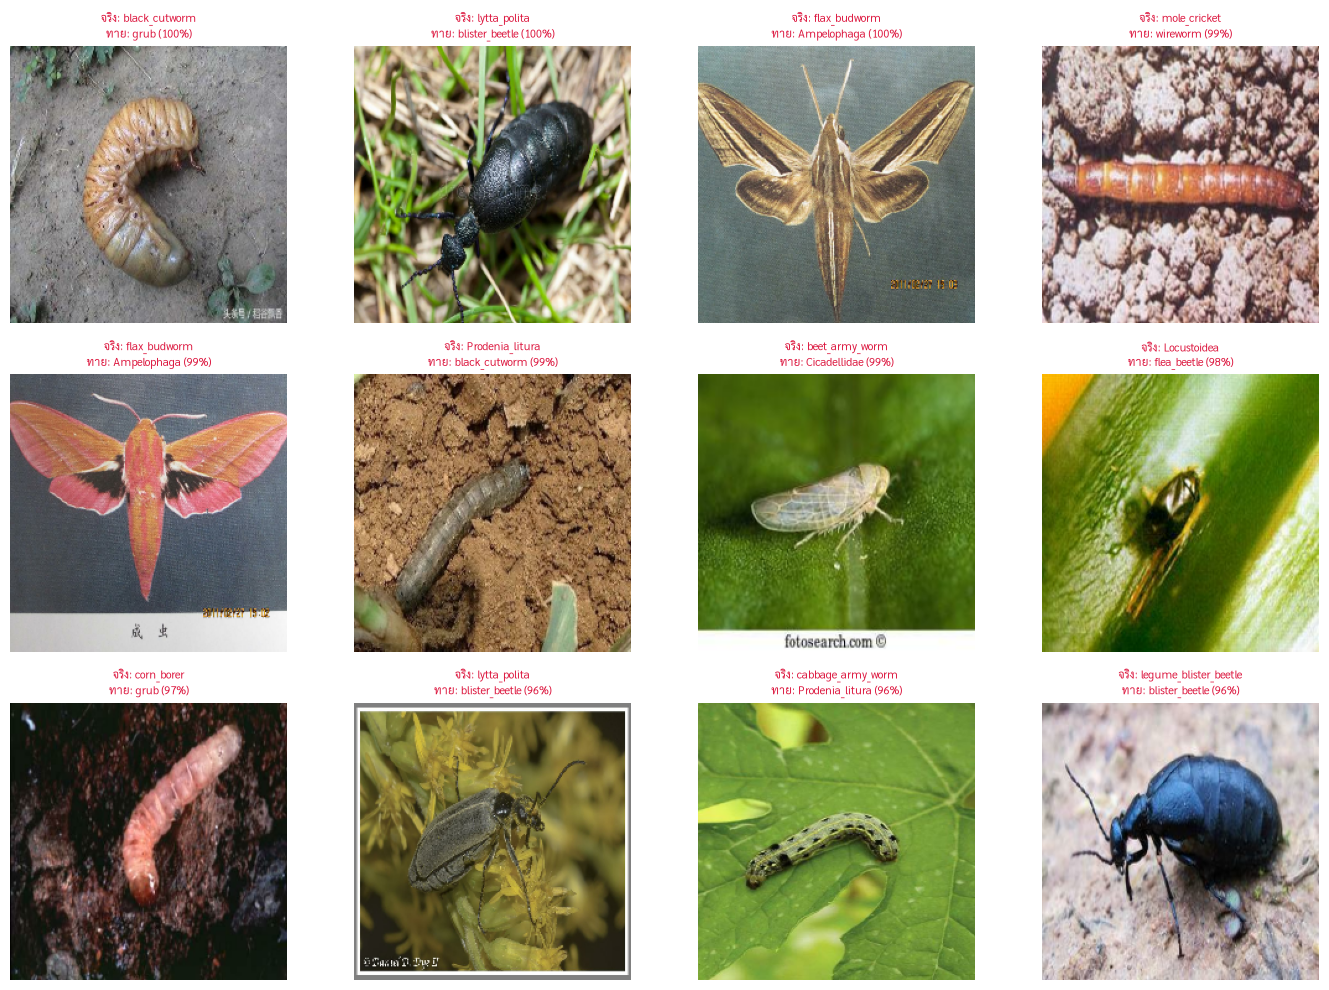

ทายผิด 424 ภาพ จาก 1994 ภาพ


In [21]:
val_images = np.concatenate([imgs.numpy() for imgs, _ in val_ds], axis=0)

wrong_idx = np.where(y_true != y_pred)[0]
wrong_idx = wrong_idx[np.argsort(-y_prob[wrong_idx])]

n_show = min(12, len(wrong_idx))
plt.figure(figsize=(14, 10))
for k in range(n_show):
    idx = wrong_idx[k]
    plt.subplot(3, 4, k + 1)
    plt.imshow(val_images[idx].astype('uint8'))
    plt.title(
        f"จริง: {class_names[y_true[idx]]}\nทาย: {class_names[y_pred[idx]]} ({y_prob[idx]:.0%})",
        fontsize=8, color='crimson',
    )
    plt.axis('off')
plt.tight_layout()
plt.show()

print(f"ทายผิด {len(wrong_idx)} ภาพ จาก {len(y_true)} ภาพ")

พอเห็นภาพจริงจะพบว่าความผิดพลาดมีสามแบบ และแก้คนละวิธี

- **แมลงวงศ์เดียวกัน** เช่น blister beetle กับ legume blister beetle กับ lytta polita ล้วนเป็นด้วงน้ำมัน ต่างกันที่รายละเอียดระดับที่ต้องเป็นนักกีฏวิทยาถึงจะแยกออก กลุ่มนี้แก้ด้วยการเพิ่มความละเอียดภาพ หรือยอมรับว่าควรยุบเป็นคลาสเดียวกัน
- **แมลงเล็กเกินไปในเฟรม** ภาพถ่ายในไร่จริงหลายภาพมีใบไม้เต็มเฟรมและแมลงตัวจิ๋วอยู่มุมหนึ่ง พอย่อเหลือ 224×224 รายละเอียดหายหมด กลุ่มนี้ต้อง crop ก่อนหรือใช้ความละเอียดสูงขึ้น
- **ระยะการเจริญเติบโตต่างกัน** ภาพตัวอ่อน (หนอน) กับตัวเต็มวัย (ผีเสื้อ/ด้วง) ของแมลงชนิดเดียวกันหน้าตาคนละเรื่อง แต่อยู่คลาสเดียวกัน ทำให้โมเดลต้องเรียนสองแบบในคลาสเดียว

ข้อสังเกตสำคัญ: ตัวเลข accuracy รวมของงานนี้จะดูต่ำเมื่อเทียบกับงานจำแนกดอกไม้หรือสัตว์เลี้ยง แต่ไม่ได้แปลว่าโมเดลแย่ - โจทย์นี้ยากกว่าจริง ๆ และมีเพดานที่ต่ำกว่า 100% อยู่แล้ว งานวิจัยที่ใช้ IP102 เต็มชุด 102 คลาสก็ทำได้ราว 60-75% เท่านั้น

## 7. สรุปผล

In [22]:
baseline_trainable = sum(int(tf.size(w)) for w in baseline.trainable_weights)

rows = [("baseline CNN (from scratch)", baseline_acc, baseline_trainable)]
for r in results.values():
    rows.append((f"{r['name']} - feature extract", r['fe_acc'], r['fe_trainable']))
    rows.append((f"{r['name']} - fine-tune", r['ft_acc'], r['ft_trainable']))

print(f"{'method':<36}{'val accuracy':<16}{'trainable params'}")
print("-" * 70)
for name, acc, params in rows:
    print(f"{name:<36}{acc:<16.4f}{params:,}")

print()
print(f"ดีที่สุด: {best['name']} (fine-tune) ที่ {best['ft_acc']:.4f}")
print(f"ดีกว่า baseline {(best['ft_acc'] - baseline_acc) * 100:+.2f} จุด")

method                              val accuracy    trainable params
----------------------------------------------------------------------
baseline CNN (from scratch)         0.3701          393,556
EfficientNetV2B0 - feature extract  0.7743          25,620
EfficientNetV2B0 - fine-tune        0.7874          1,179,252
ResNet50V2 - feature extract        0.7452          40,980
ResNet50V2 - fine-tune              0.7859          14,467,092

ดีที่สุด: EfficientNetV2B0 (fine-tune) ที่ 0.7874
ดีกว่า baseline +41.73 จุด


### สรุป

Baseline CNN ที่ฝึกจากศูนย์ทำได้ราว 20-30% ส่วน feature extraction ที่ฝึกพารามิเตอร์แค่หลักหมื่นตัวทำได้สูงกว่าหลายเท่าตั้งแต่ epoch แรก ๆ ความรู้จาก ImageNet ถ่ายทอดมาใช้กับภาพแมลงได้จริง ทั้งที่ ImageNet ไม่ได้ฝึกมาเพื่อแยกแมลงศัตรูพืชโดยเฉพาะ จากนั้น fine-tuning ต่อยอดได้อีก แต่ต้องลด learning rate ลง 100 เท่า

เรื่อง base model: ResNet50V2 มีพารามิเตอร์มากกว่า EfficientNetV2B0 ราวสี่เท่า แต่ตัวเลขในตารางข้างบนบอกว่าส่วนต่างของความแม่นไม่ได้มากตามขนาด โมเดลใหญ่กว่าไม่ได้แปลว่าดีกว่าเสมอ โดยเฉพาะเมื่อข้อมูลมีจำกัด ที่สำคัญกว่าคือ feature ที่ base model เรียนมาตรงกับโจทย์แค่ไหน

ผลที่ได้บนโจทย์นี้ต่ำกว่างานจำแนกดอกไม้มาก ซึ่งสมเหตุสมผล เพราะ 20 คลาสที่หลายตัวเป็นแมลงวงศ์เดียวกัน ถ่ายในไร่จริง มีใบไม้บังและแมลงตัวเล็กในเฟรม เป็นโจทย์ที่ยากกว่าจริง ๆ confusion matrix จะบอกว่าโมเดลสับสนคู่ไหน ซึ่งมักเป็นคู่ที่คนก็แยกยากเหมือนกัน

ลองต่อได้: เพิ่ม `ConvNeXtTiny` หรือ `EfficientNetV2S` เข้าไปใน `CONFIGS` (อย่าลืมใส่ `preprocess` ให้ตรง), ปรับ `fine_tune_layers`, ใส่ `class_weight` ชดเชยคลาสที่ไม่สมดุล (สำคัญมากกับชุดนี้), เพิ่ม `N_CLASSES` เป็น 50 หรือใช้ครบ 97 คลาส, หรือใช้ `EarlyStopping` แทนการกำหนด epoch ตายตัว